In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load retention dataset exported from SQL
df = pd.read_csv(r"C:\Users\dell\Documents\customer-retention-cohort-analysis\data\cleaned\cohort_retention.csv")

df.head()

,cohort_month,cohort_index,active_customers,total_customers,retention_percentage
0,12/1/2010 0:00,0,885,885,100.00
1,12/1/2010 0:00,1,324,885,36.61
2,12/1/2010 0:00,2,286,885,32.32
3,12/1/2010 0:00,3,340,885,38.42
4,12/1/2010 0:00,4,321,885,36.27


In [3]:
# Pivot table for retention %
cohort_pivot = df.pivot_table(
    index="cohort_month",
    columns="cohort_index",
    values="retention_percentage"
)

cohort_pivot.head()

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12
cohort_month,,,,,,,,,,,,,
1/1/2011 0:00,100.0,22.06,26.62,23.02,32.13,28.78,24.70,24.22,29.98,32.61,36.45,11.75,NaN
10/1/2011 0:00,100.0,24.02,11.45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11/1/2011 0:00,100.0,11.11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12/1/2010 0:00,100.0,36.61,32.32,38.42,36.27,39.77,36.27,34.92,35.37,39.55,37.40,50.28,26.55
12/1/2011 0:00,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Convert to Retention Rate (0–1 Scale)
retention = cohort_pivot / 100
retention.head()

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12
cohort_month,,,,,,,,,,,,,
1/1/2011 0:00,1.0,0.2206,0.2662,0.2302,0.3213,0.2878,0.2470,0.2422,0.2998,0.3261,0.3645,0.1175,NaN
10/1/2011 0:00,1.0,0.2402,0.1145,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11/1/2011 0:00,1.0,0.1111,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12/1/2010 0:00,1.0,0.3661,0.3232,0.3842,0.3627,0.3977,0.3627,0.3492,0.3537,0.3955,0.3740,0.5028,0.2655
12/1/2011 0:00,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


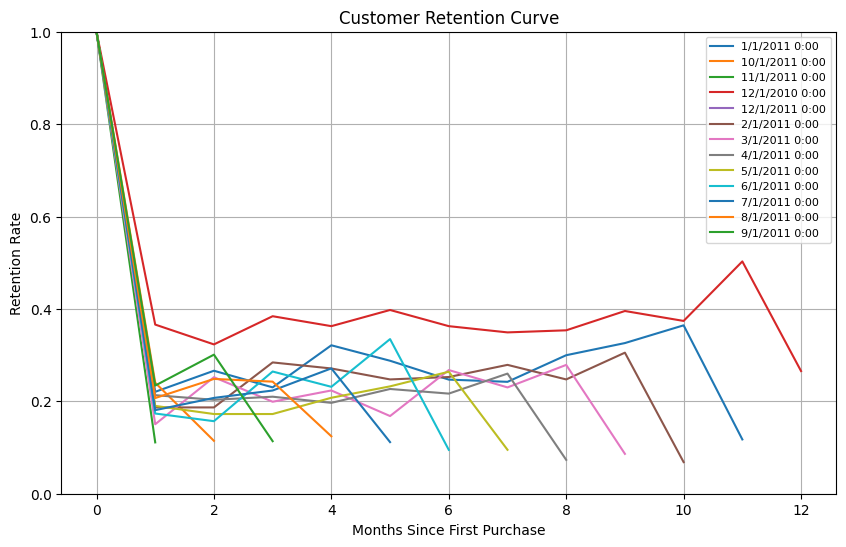

In [6]:
# Plot Retention Curve
plt.figure(figsize=(10,6))

for cohort in retention.index:
    plt.plot(retention.columns, retention.loc[cohort], label=str(cohort))

plt.title("Customer Retention Curve")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Retention Rate")
plt.legend(loc="upper right", fontsize=8)
plt.grid(True)
plt.ylim(0, 1)

plt.show()